# Walk-Forward Parameter Validation

**Purpose.** `research.ipynb` asks "does this signal work over the whole history
with one fixed parameter set". This notebook asks the harder, more important
question institutionally: **if we'd had to pick that parameter set using only the
data available at the time, would it still have worked out-of-sample, on data it
never saw during selection?**

A backtest optimized once over the full history and never checked this way is not
a "wrong" backtest -- it's an *unvalidated* one. Walk-forward analysis is the
standard defense against silently overfitting to a specific historical sample.

**Method (rolling walk-forward):**

1. Split history into sequential (in-sample, out-of-sample) folds.
2. In each fold, run the full `(fast_window, slow_window)` grid on the IN-SAMPLE
   slice only, and pick the combo with the best in-sample Sharpe.
3. Apply that *same, already-chosen* combo to the OUT-OF-SAMPLE slice immediately
   following it -- data the selection step never saw.
4. Stitch the OOS segments from every fold together into one continuous
   walk-forward equity curve, and compare it to (a) a single fixed parameter set
   never reoptimized, and (b) buy & hold.
5. Look for the classic overfitting signature: in-sample Sharpe consistently much
   higher than out-of-sample Sharpe, or a "best" parameter that swings wildly from
   fold to fold.

## 0. Setup

In [30]:
import sys
from pathlib import Path

# Make sure the project root (where config.py lives) is importable, no matter which directory
# Jupyter was launched from. Fixes the classic "ModuleNotFoundError: No module named 'config'" 
# when the kernel's working directory isn't the project root.

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config.py").exists() and (PROJECT_ROOT.parent / "config.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/davidyekara/Downloads/Algorithmic Trading Cookbook/VectorBT/Technical Strategies


In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import config
import database
from strategy_engine import get_strategy, STRATEGY_REGISTRY, ma_crossover_grid
from signal_generator import SignalGenerator, signals_to_position_state
import portfolio_engine
from backtester import run_backtest, run_buy_and_hold, run_parameter_sweep
from performance_analytics import (
    summary_stats, 
    portfolio_level_stats, 
    compare_to_benchmark,
    portfolio_equity,
    )
from feature_engine import FeatureEngine

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ALLOCATORS = {
    "equal_weight": (portfolio_engine.equal_weight, {}),
    "volatility_weight": (portfolio_engine.volatility_weight, None),   # needs returns, filled in below
    "risk_parity": (portfolio_engine.risk_parity, None),
    "kelly_weight": (portfolio_engine.kelly_weight, None),
}

In [32]:
database.init_db()
prices = database.load_bars(config.UNIVERSE)
assert not prices.empty, "No data in DB yet -- run `python main.py refresh` first."

log_returns = np.log(prices / prices.shift(1))
for name, (fn, kwargs) in ALLOCATORS.items():
    if kwargs is None:
        ALLOCATORS[name] = (fn, {"returns": log_returns})

print(f"Universe: {list(prices.columns)}")
print(f"Date range: {prices.index.min().date()} -> {prices.index.max().date()}  ({len(prices)} bars)")
prices.tail()

Universe: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'GOOG']
Date range: 2018-07-24 -> 2026-08-17  (2027 bars)


symbol,AAPL,AMZN,MSFT,NVDA,GOOG
datetime,,,,,
2026-08-11,304.9100,272.2700,503.8100,217.5000,343.0000
2026-08-12,302.2500,267.2800,492.4300,224.0900,342.3700
2026-08-13,305.2600,265.1300,496.8800,225.3000,343.9400
2026-08-14,305.9300,262.6500,495.4000,225.1600,343.5400
2026-08-17,305.5900,261.3100,480.3500,225.0100,341.4500


## 1. Walk-forward fold generator

Rolling (not expanding) windows: each fold uses a fixed-length in-sample window
immediately followed by a fixed-length out-of-sample window, then the whole
window slides forward by the OOS length (so OOS segments never overlap and can be
stitched end-to-end into one continuous track record).

In [23]:
IS_DAYS = 252 * 2     # ~2 years in-sample
OOS_DAYS = 63         # ~1 quarter out-of-sample, non-overlapping across folds
STEP_DAYS = OOS_DAYS  # slide forward by exactly one OOS window each fold

FAST_WINDOWS = [20, 50, 100]
SLOW_WINDOWS = [200, 300, 400]

def walk_forward_folds(index: pd.DatetimeIndex, is_days: int, oos_days: int, step_days: int):
    """Yield (is_start, is_end, oos_start, oos_end) index-position tuples."""
    folds = []
    start = 0
    while start + is_days + oos_days <= len(index):
        is_start = start
        is_end = start + is_days          # exclusive
        oos_start = is_end
        oos_end = is_end + oos_days        # exclusive
        folds.append((is_start, is_end, oos_start, oos_end))
        start += step_days
    return folds

folds = walk_forward_folds(prices.index, IS_DAYS, OOS_DAYS, STEP_DAYS)
print(f"{len(folds)} folds generated "
      f"(in-sample={IS_DAYS}d, out-of-sample={OOS_DAYS}d, step={STEP_DAYS}d)")
for i, (a, b, c, d) in enumerate(folds):
    print(f"  fold {i}: IS {prices.index[a].date()} -> {prices.index[b-1].date()}   "
          f"OOS {prices.index[c].date()} -> {prices.index[d-1].date()}")

24 folds generated (in-sample=504d, out-of-sample=63d, step=63d)
  fold 0: IS 2018-07-24 -> 2020-07-23   OOS 2020-07-24 -> 2020-10-21
  fold 1: IS 2018-10-22 -> 2020-10-21   OOS 2020-10-22 -> 2021-01-22
  fold 2: IS 2019-01-24 -> 2021-01-22   OOS 2021-01-25 -> 2021-04-23
  fold 3: IS 2019-04-25 -> 2021-04-23   OOS 2021-04-26 -> 2021-07-23
  fold 4: IS 2019-07-25 -> 2021-07-23   OOS 2021-07-26 -> 2021-10-21
  fold 5: IS 2019-10-23 -> 2021-10-21   OOS 2021-10-22 -> 2022-01-21
  fold 6: IS 2020-01-24 -> 2022-01-21   OOS 2022-01-24 -> 2022-04-22
  fold 7: IS 2020-04-24 -> 2022-04-22   OOS 2022-04-25 -> 2022-07-25
  fold 8: IS 2020-07-24 -> 2022-07-25   OOS 2022-07-26 -> 2022-10-21
  fold 9: IS 2020-10-22 -> 2022-10-21   OOS 2022-10-24 -> 2023-01-24
  fold 10: IS 2021-01-25 -> 2023-01-24   OOS 2023-01-25 -> 2023-04-25
  fold 11: IS 2021-04-26 -> 2023-04-25   OOS 2023-04-26 -> 2023-07-26
  fold 12: IS 2021-07-26 -> 2023-07-26   OOS 2023-07-27 -> 2023-10-24
  fold 13: IS 2021-10-22 -> 2023-10

## 2. Per-fold optimization + out-of-sample evaluation

For each fold: run the whole `(fast, slow)` grid across the IS+OOS window in one
`ma_crossover_grid` call (this also gives every candidate the correct indicator
warm-up history), pick the IS winner by Sharpe, then read that SAME combo's OOS
performance off the same portfolio object -- the OOS segment was never used for
selection, only for evaluation.

In [ ]:
def evaluate_fold(prices_fold, is_end_ts, oos_start_ts, oos_end_ts,
                  allocator=portfolio_engine.equal_weight,
                  allocator_kwargs=None):

    allocator_kwargs = allocator_kwargs or {}

    best = None
    best_is_sharpe = -np.inf
    best_oos_sharpe = np.nan
    best_oos_series = None

    for fast in FAST_WINDOWS:
        for slow in SLOW_WINDOWS:

            entries, exits = ma_crossover_grid(prices_fold, fast, slow) # type: ignore

            entries = entries.xs((fast, slow), axis=1, level=("fast_window", "slow_window"))
            exits = exits.xs((fast, slow), axis=1, level=("fast_window", "slow_window"))

            pf = run_backtest(prices_fold, entries, exits, allocator=allocator, allocator_kwargs=allocator_kwargs)

            returns = pf.returns()

            is_returns = returns.loc[:is_end_ts]
            oos_returns = returns.loc[oos_start_ts:oos_end_ts]

            portfolio_is = is_returns.mean(axis=1)
            portfolio_oos = oos_returns.mean(axis=1)

            if portfolio_is.std() == 0:
                continue

            is_sharpe = (portfolio_is.mean() / portfolio_is.std()) * np.sqrt(252)
            oos_sharpe = (portfolio_oos.mean() / portfolio_oos.std()) * np.sqrt(252)

            if is_sharpe > best_is_sharpe:
                best_is_sharpe = is_sharpe
                best_oos_sharpe = oos_sharpe
                best_oos_series = portfolio_oos
                best = (fast, slow)

    return {
        "best_fast_window": best[0], # type: ignore
        "best_slow_window": best[1], # type: ignore
        "is_sharpe": best_is_sharpe,
        "oos_sharpe": best_oos_sharpe,
        "oos_return_series": best_oos_series,
    }

In [37]:
fold_results = []
for i, (a, b, c, d) in enumerate(folds):
    prices_fold = prices.iloc[a:d]
    is_end_ts = prices.index[b - 1]
    oos_start_ts = prices.index[c]
    oos_end_ts = prices.index[d - 1]
    result = evaluate_fold(prices_fold, is_end_ts, oos_start_ts, oos_end_ts)
    result["fold"] = i
    result["is_end"] = is_end_ts
    result["oos_start"] = oos_start_ts
    result["oos_end"] = oos_end_ts
    fold_results.append(result)
    print(f"fold {i}: best=({result['best_fast_window']},{result['best_slow_window']})  "
          f"IS Sharpe={result['is_sharpe']:.2f}  OOS Sharpe={result['oos_sharpe']:.2f}")

fold 0: best=(20,300)  IS Sharpe=1.30  OOS Sharpe=1.84
fold 1: best=(50,200)  IS Sharpe=1.41  OOS Sharpe=0.90
fold 2: best=(20,200)  IS Sharpe=1.38  OOS Sharpe=0.60
fold 3: best=(20,200)  IS Sharpe=1.46  OOS Sharpe=3.03
fold 4: best=(100,200)  IS Sharpe=1.75  OOS Sharpe=0.81
fold 5: best=(20,200)  IS Sharpe=0.09  OOS Sharpe=-1.17
fold 6: best=(20,200)  IS Sharpe=-0.17  OOS Sharpe=-4.74
fold 7: best=(50,200)  IS Sharpe=-0.65  OOS Sharpe=nan
fold 8: best=(20,200)  IS Sharpe=-1.51  OOS Sharpe=-2.72
fold 9: best=(50,300)  IS Sharpe=-0.52  OOS Sharpe=nan
fold 10: best=(50,300)  IS Sharpe=-0.52  OOS Sharpe=0.66
fold 11: best=(50,200)  IS Sharpe=0.73  OOS Sharpe=4.35
fold 12: best=(50,200)  IS Sharpe=1.67  OOS Sharpe=-0.30
fold 13: best=(50,200)  IS Sharpe=1.20  OOS Sharpe=4.21
fold 14: best=(50,200)  IS Sharpe=1.84  OOS Sharpe=1.54
fold 15: best=(100,200)  IS Sharpe=1.56  OOS Sharpe=2.19
fold 16: best=(20,200)  IS Sharpe=1.25  OOS Sharpe=0.17
fold 17: best=(20,300)  IS Sharpe=0.82  OOS Sharp

## 3. Fold summary table & parameter stability

If the "best" `(fast, slow)` combo is essentially random from fold to fold, the
optimizer is chasing noise, not a persistent edge -- that's a red flag regardless
of how good the aggregate OOS number looks.

In [26]:
summary = pd.DataFrame([{
    "fold": r["fold"], "oos_start": r["oos_start"].date(), "oos_end": r["oos_end"].date(),
    "best_fast": r["best_fast_window"], "best_slow": r["best_slow_window"],
    "is_sharpe": r["is_sharpe"], "oos_sharpe": r["oos_sharpe"],
} for r in fold_results])
summary

,fold,oos_start,oos_end,best_fast,best_slow,is_sharpe,oos_sharpe
0,0,2020-07-24,2020-10-21,20,300,1.2992,1.8390
1,1,2020-10-22,2021-01-22,50,200,1.4057,0.9033
2,2,2021-01-25,2021-04-23,20,200,1.3828,0.5969
3,3,2021-04-26,2021-07-23,20,200,1.4556,3.0323
4,4,2021-07-26,2021-10-21,100,200,1.7545,0.8053
5,5,2021-10-22,2022-01-21,20,200,0.0939,-1.1673
6,6,2022-01-24,2022-04-22,20,200,-0.1681,-4.7429
7,7,2022-04-25,2022-07-25,50,200,-0.6480,NaN
8,8,2022-07-26,2022-10-21,20,200,-1.5118,-2.7225
9,9,2022-10-24,2023-01-24,50,300,-0.5178,NaN


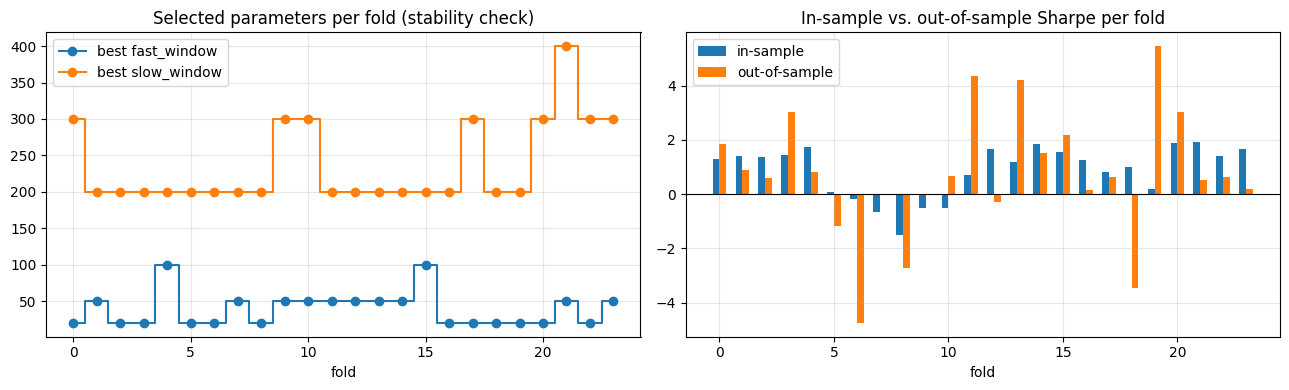

Average IS -> OOS Sharpe degradation: 0.18 (reasonable)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].step(summary["fold"], summary["best_fast"], where="mid", label="best fast_window", marker="o")
axes[0].step(summary["fold"], summary["best_slow"], where="mid", label="best slow_window", marker="o")
axes[0].set_title("Selected parameters per fold (stability check)")
axes[0].set_xlabel("fold"); axes[0].legend()

axes[1].bar(summary["fold"] - 0.15, summary["is_sharpe"], width=0.3, label="in-sample")
axes[1].bar(summary["fold"] + 0.15, summary["oos_sharpe"], width=0.3, label="out-of-sample")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("In-sample vs. out-of-sample Sharpe per fold")
axes[1].set_xlabel("fold"); axes[1].legend()
plt.tight_layout()
plt.show()

degradation = (summary["is_sharpe"] - summary["oos_sharpe"]).mean()
print(f"Average IS -> OOS Sharpe degradation: {degradation:.2f} "
      f"({'CONCERNING -- large IS/OOS gap' if degradation > 0.5 else 'reasonable'})")

## 4. Stitched walk-forward equity curve

Chain every fold's out-of-sample segment end-to-end: this is the honest,
never-peeked-at-the-future equity curve. Compare it against (a) a single fixed
parameter set optimized once and never touched again, and (b) buy & hold.

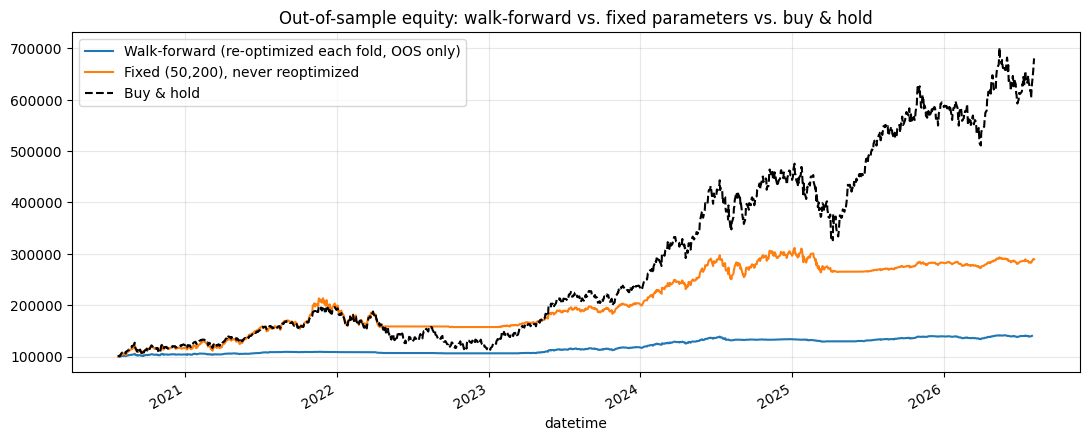

Walk-forward OOS Sharpe: 1.20   Total OOS return: 40.0%


In [28]:
oos_returns_stitched = pd.concat([r["oos_return_series"] for r in fold_results]).sort_index()
oos_returns_stitched = oos_returns_stitched[~oos_returns_stitched.index.duplicated()]
walk_forward_equity = (1 + oos_returns_stitched).cumprod() * config.RISK.initial_capital

# Baseline: today's config.DEFAULT_STRATEGY window, fixed for the whole period, never reoptimized
strategy = get_strategy(config.DEFAULT_STRATEGY.name)
sig_gen = SignalGenerator(strategy)
fixed_entries, fixed_exits = sig_gen.full_history_signals(prices)
fixed_pf = run_backtest(prices, fixed_entries, fixed_exits)
fixed_equity, fixed_returns = portfolio_equity(fixed_pf, prices)
fixed_equity = fixed_equity.loc[walk_forward_equity.index[0]:]
fixed_equity = fixed_equity / fixed_equity.iloc[0] * config.RISK.initial_capital

hold_pf = run_buy_and_hold(prices)
hold_equity, hold_returns = portfolio_equity(hold_pf, prices)
hold_equity = hold_equity.loc[walk_forward_equity.index[0]:]
hold_equity = hold_equity / hold_equity.iloc[0] * config.RISK.initial_capital

fig, ax = plt.subplots()
walk_forward_equity.plot(ax=ax, label="Walk-forward (re-optimized each fold, OOS only)")
fixed_equity.plot(ax=ax, label=f"Fixed ({config.DEFAULT_STRATEGY.fast_window},{config.DEFAULT_STRATEGY.slow_window}), never reoptimized")
hold_equity.plot(ax=ax, label="Buy & hold", color="black", linestyle="--")
ax.set_title("Out-of-sample equity: walk-forward vs. fixed parameters vs. buy & hold")
ax.legend()
plt.show()

wf_sharpe = (oos_returns_stitched.mean() / oos_returns_stitched.std()) * np.sqrt(252)
wf_total_return = walk_forward_equity.iloc[-1] / walk_forward_equity.iloc[0] - 1
print(f"Walk-forward OOS Sharpe: {wf_sharpe:.2f}   Total OOS return: {wf_total_return*100:.1f}%")

## 5. Interpretation checklist

- **Parameter stability (section 3, left panel):** does the same handful of
  `(fast, slow)` combos keep winning, or is it different every fold? Wild swings
  suggest the grid is fitting noise rather than a persistent pattern.
- **IS/OOS Sharpe gap (section 3, right panel):** a small, consistent gap is
  normal and expected (OOS is always somewhat worse). A large or highly variable
  gap is the standard overfitting signature.
- **Walk-forward vs. fixed vs. buy & hold (section 4):** if the walk-forward line
  doesn't meaningfully beat the naive fixed-parameter line, the reoptimization
  step isn't adding value -- it's just adding complexity and risk of overfitting.
- **Sample size:** with only a handful of folds, none of the above is statistically
  reliable. Treat this as a first filter, not a final verdict -- widen the
  history, shrink the OOS window, or gather more data before making a capital
  decision on a handful of folds.

If this looks acceptable, the parameter set (or the walk-forward re-optimization
process itself, if you intend to run it live) is ready for a full PM-facing risk
review in `portfolio_analysis.ipynb`.